## Quantile binning

In this notebook, we work on discretizing treatment according to treatment dosage quantile, so that every discrete treatment level has the same number of samples.

In [16]:
import pandas as pd
import sys
sys.path.append("../../..")
import numpy as np
import torch
import matplotlib.pyplot as plt

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [17]:
# Discretization function
def discretize_treatment(T: np.ndarray, N: int) -> tuple[np.ndarray, np.ndarray]:
    """Returns quantile method discretized version of T. Assumes range of T is [0, 1].

    Args:
        T (np.ndarray): The raw treatment data 
        N (int): The number of bins (equiv to the number of discrete treatment values)

    Returns:
        np.ndarray: The discretized treatment data (expected outcomes)
        np.ndarray: The discretized treatment values
    """
    T_discrete = np.zeros(T.shape)
    T_vals = np.zeros((N,))
    bin_edges = np.percentile(T, np.linspace(0, 100, N + 1))
    for i in range(len(bin_edges) - 1):
        left_edge = bin_edges[i]
        right_edge = bin_edges[i + 1]
        ids = (T >= left_edge) & (T <= right_edge)
        avg = np.mean(T[ids])
        T_discrete[ids] = avg
        T_vals[i] = avg

    return T_discrete, T_vals

In [18]:
## Synthetic data generation
data_name = "vahid-linear"

np.random.seed(42)
n, d = 2000, 3
X = np.random.normal(1, 1, size=(n, d)).astype(np.float32)
T = (X[:, 0] - X[:, 1] + 2 * X[:, 2] + 2 + np.random.normal(0, 3, size=n)).astype(np.float32)
T = T - T.min() # Rescale
T = T / T.max() # Rescale
Y = (3 * X[:, 0] + X[:, 1] - 0.5 * X[:, 2] + 3 * T + np.random.normal(0, 2, size=n)).astype(np.float32)
def drf(t): return 3.5 + 3 * t # true dose-response function

df = pd.concat([
    pd.DataFrame(data=X, columns=["x1", "x2", "x3"]), 
    pd.DataFrame(data=T, columns=["T"]), 
    pd.DataFrame(data=Y, columns=["Y"])
    ], axis=1)


In [19]:
# ## Synthetic data generation
# data_name = "ADMIT-synthetic"
# # DGP from https://github.com/CausalTeam/ADMIT/blob/main
# def sigmoid(t): return 1. / (1. + np.exp(-1. * t))
# n, d = 2000, 6
# X = np.random.uniform(-1, 1, (n, d))
# x1 = X[:, 0]
# x2 = X[:, 1]
# x3 = X[:, 2]
# x4 = X[:, 3]
# x5 = X[:, 4]
# x6 = X[:, 5]
# # Generate treatment 
# mu_1 =  (10. * np.sin(np.maximum(x1, np.maximum(x2, x3))) + np.maximum(x3, np.maximum(x4, x5))**3)/(1. + (x1 + x5)**2) + np.sin(0.5 * x3) * (1. + np.exp(x4 - 0.5 * x3)) + x3**2 + 2. * np.sin(x4) + 2.*x5 - 6.5
# T = np.random.normal(mu_1, 0.5)
# T = sigmoid(T)
# # Generate outcomes
# mu_2 = np.cos(2 * np.pi * (T - 0.5)) * (T ** 2 + (4 * np.maximum(x1, x6) ** 3) * np.sin(x4) / (1 + 2 * x3 ** 2))
# Y = np.random.normal(mu_2, 0.5)

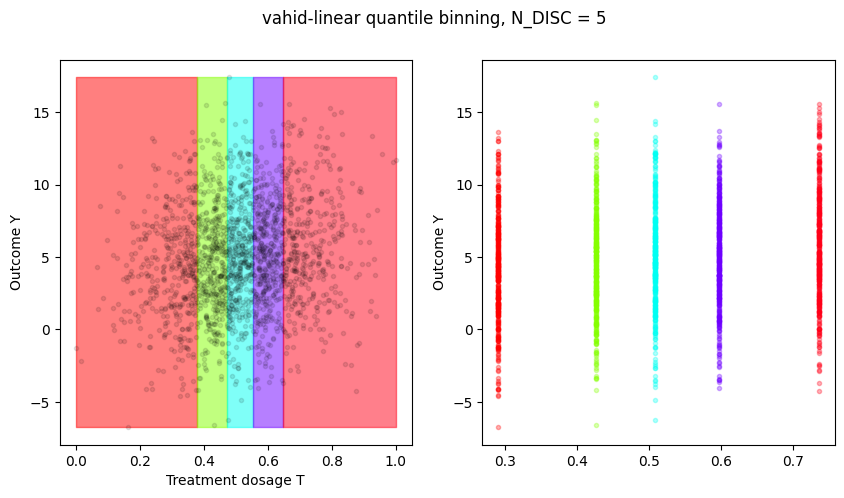

In [24]:
# Visualization of the discretization process. Change N_DISC below.
N_DISC = 5
T_discrete, T_vals = discretize_treatment(T, N_DISC)

bin_edges = np.percentile(T, np.linspace(0, 100, N_DISC + 1))
plt.figure(figsize=(10, 5))
c_map = plt.get_cmap("hsv", N_DISC) # new color for each discrete dosage 
i = 0
plt.subplot(1, 2, 1)
plt.plot(T, Y, '.', alpha=0.1, c="k") # plot the data
for idx in range(N_DISC):
    left_edge = bin_edges[i]
    right_edge = bin_edges[i + 1]
    ids = (T >= left_edge) & (T <= right_edge)
    avg = np.mean(T[ids])
    plt.fill_betweenx(y=[Y.min(), Y.max()], # plot the discrete treatment regions 
                      x1=left_edge, 
                      x2=right_edge,
                      color=c_map(i), alpha=0.5)
    i += 1
plt.xlabel("Treatment dosage T")
plt.ylabel("Outcome Y")

plt.subplot(1, 2, 2)
i = 0
for idx in range(N_DISC):
    left_edge = bin_edges[i]
    right_edge = bin_edges[i + 1]
    ids = (T >= left_edge) & (T <= right_edge)
    avg = np.mean(T[ids])
    plt.plot(T_discrete[ids], Y[ids], '.', alpha=0.3, c=c_map(i))
    i += 1
plt.ylabel("Outcome Y")

plt.suptitle(f"{data_name} quantile binning, N_DISC = {N_DISC}")

plt.show()

In [25]:
print(f"T_vals: {T_vals}")

T_vals: [0.29128221 0.42721573 0.50942111 0.59697974 0.73603654]


In [26]:
# Verify evenly-distributed
for val in np.unique(T_discrete):
    ids = (T_discrete == val)
    print(f"# samples discretized to {val:.3f}: {ids.sum()}")

# samples discretized to 0.291: 400
# samples discretized to 0.427: 400
# samples discretized to 0.509: 400
# samples discretized to 0.597: 400
# samples discretized to 0.736: 400


## Module testing

Below, we test our custom module and class and make sure we get the same results

In [27]:
%load_ext autoreload
%autoreload 2
import numpy as np
import sys
sys.path.append("../discretized-causalpfn")
from discretize import DataDiscretizer
from inference import DiscreteCausalPFN

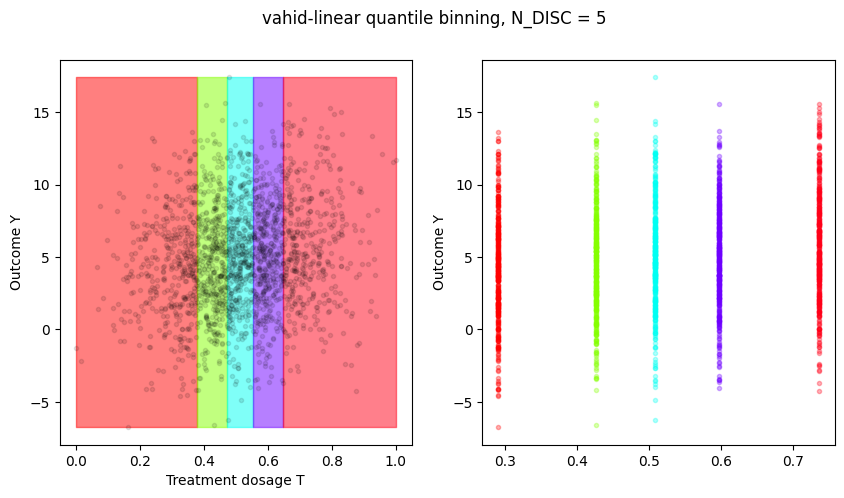

In [28]:
# Visualization of the discretization process. Change N_DISC below.
N_DISC = 5
discretizer = DataDiscretizer("quantile")
T_discrete, T_vals = discretizer.discretize_treatment(T, N_DISC)

bin_edges = np.percentile(T, np.linspace(0, 100, N_DISC + 1))
plt.figure(figsize=(10, 5))
c_map = plt.get_cmap("hsv", N_DISC) # new color for each discrete dosage 
i = 0
plt.subplot(1, 2, 1)
plt.plot(T, Y, '.', alpha=0.1, c="k") # plot the data
for idx in range(N_DISC):
    left_edge = bin_edges[i]
    right_edge = bin_edges[i + 1]
    ids = (T >= left_edge) & (T <= right_edge)
    avg = np.mean(T[ids])
    plt.fill_betweenx(y=[Y.min(), Y.max()], # plot the discrete treatment regions 
                      x1=left_edge, 
                      x2=right_edge,
                      color=c_map(i), alpha=0.5)
    i += 1
plt.xlabel("Treatment dosage T")
plt.ylabel("Outcome Y")

plt.subplot(1, 2, 2)
i = 0
for idx in range(N_DISC):
    left_edge = bin_edges[i]
    right_edge = bin_edges[i + 1]
    ids = (T >= left_edge) & (T <= right_edge)
    avg = np.mean(T[ids])
    plt.plot(T_discrete[ids], Y[ids], '.', alpha=0.3, c=c_map(i))
    i += 1
plt.ylabel("Outcome Y")

plt.suptitle(f"{data_name} quantile binning, N_DISC = {N_DISC}")

plt.show()